<a href="https://colab.research.google.com/github/imdark/AR_Robot/blob/master/OR_TakeHomeChallenge_TreeCounter2_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

This is the Orchard Robotics Take-Home challenge. This challenge tests a wide variety of skills, and encompasses multiple sections, each of which will be graded separately from the others.

*This challenge is meant to be challenging*, and while we do not expect you to complete all parts to 100%, we would like to see your best efforts at completing the challenge. Showing evidence of your exceptional ability by going above-and-beyond on these tasks is always great to see.

*We encourage creative and inventive solutions! This challenge is very open-ended, with minimal constraints. We want to see what you can do when tasked with a realistically-inspired challenge, similar to those we face and overcome every day during our work at Orchard Robotics.*

In total, this challenge should not take more than 2-3 hours to complete.

If you have any questions at any time, feel free to email contact@orchard-robotics.com for any clarifications that might be helpful.

Start by making a copy of this challenge (go to File -> Save a copy in Drive).

After you complete the challenge and you are ready to submit, to share your Colab notebook, go to Share (in the top right corner), and turn on link sharing for anybody with the link.

**Goal**

In this challenge, you will be given multiple forms of sensor data, coming directly from our in-field camera systems. These data include:
1. RGB images of the bottoms of trees, taken by the camera
2. Corresponding depth maps for each of the RGB images

These sensor data are from a "scan" of a single row in an apple orchard. There will be 49 frames (for each of the RGB image and depth images), which were taken at approximately 10 frames per second from the camera system, as the camera system was driven past trees in a row of an apple orchard.

This sensor data is "real-world data" and will be noisy and imperfect. You may compensate for this by adding in intelligent filtering to your code.

Your main task is to take this data and **count the total number of trees imaged within this "scan"** of the row in the apple orchard.

**Rules**

You may use any and all resources on the internet at your disposal. However, you may not directly copy or plagarize code found from the internet. You may also use any python libraries that can be installed via pip. You may not consult other people on advice to solve this challenge. However, you are allowed to use tools such as ChatGPT, Cursor, Windsurf, etc, with some disclaimers:

**If you are using code generated by an AI tool, you must disclose when/where that code is used. You must also provide detailed explanation of why you need that code and what that code does. We evaluate your submission based on the code you have written and if there is no such explanation, we won't be able to evaluate and proceed to the next stage.**


**Submission**

* **You must send us only a single link to the Colab notebook with your solution and nothing else!** We should be able to reproduce your results by running the notebook.
* Include your detailed comments and explanations on the decisions that you made to approach the problem, and the steps you took to work towards your solution;
* Make sure to include the estimate of approximately how much time it took you to get to the final solution.

**Colab setup**

* To use GPU, go to `Runtime -> Change Runtime Type -> GPU`

In [3]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

**`You can find all the relevant input and training files here:`**
https://drive.google.com/drive/folders/1tUNwIYE6FsUg0YnCw6vr8mA-iBvNDpRV


**Part 1**

In this part of the challenge, you must load in all of the data provided. In the Take Home Challenge folder, there are 3 subfolders.

1. The first subfolder, "EvaluationSetRGB" contains the RGB images in the scan. These images are sorted in chronological order, with the name of the file as "image-{number in sequence}.jpg"

2. The second subfolder, "EvaluationSetDepth" contains the depth maps of the scan. Each depth map is encoded as a 16-bit png, with identical dimensions to it's corresponding RGB image, where each pixel's value corresponds to the depth in millimeters at that RGB pixel. Make sure to read in this image accordingly as a 16-bit png. These depth maps are sorted in chronological order, with the name of the file as "depth-{number in sequence}.png"

4. The third subfolder, "TrainingData" will be used in Part 2.) of this challenge.


Given these input files, load them into your program, and output three values:

1. The RGB color of the 100th pixel from the left, 200th pixel from the top in the 25th image chronologically.

2. The depth of this same pixel, via the depth map, returned in millimeters.

3. The total number of pixels in this image that have depth values +/- 10 mm of the depth value you found.

*Example RGB images of tree trunks*

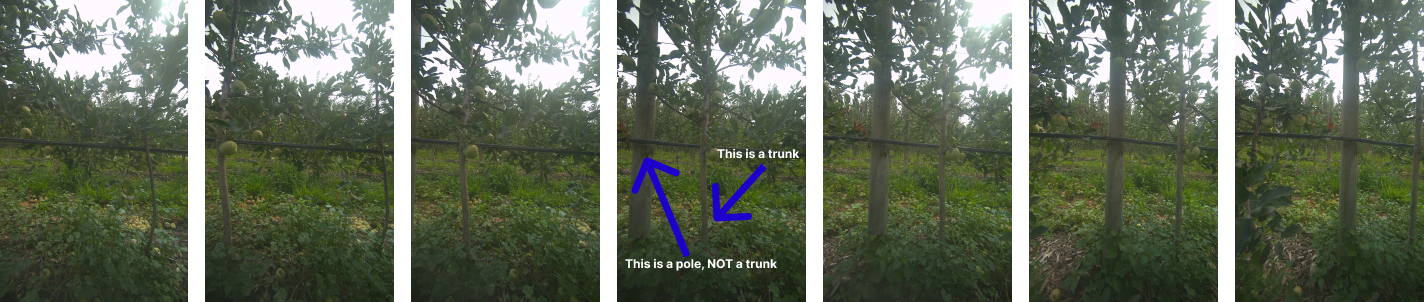

Below, we demonstrate how to use gdown to load in the files from google drive.

In [ ]:
!pip install gdown

Rgb File downloaded:  True /content/EvaluationSetRGB/025_rgb.jpg
Depth File downloaded:  True /content/EvaluationSetDepth/025_depth.png
pixel_of_interest_color: (48, 62, 36)
pixel_of_interest_color: 247


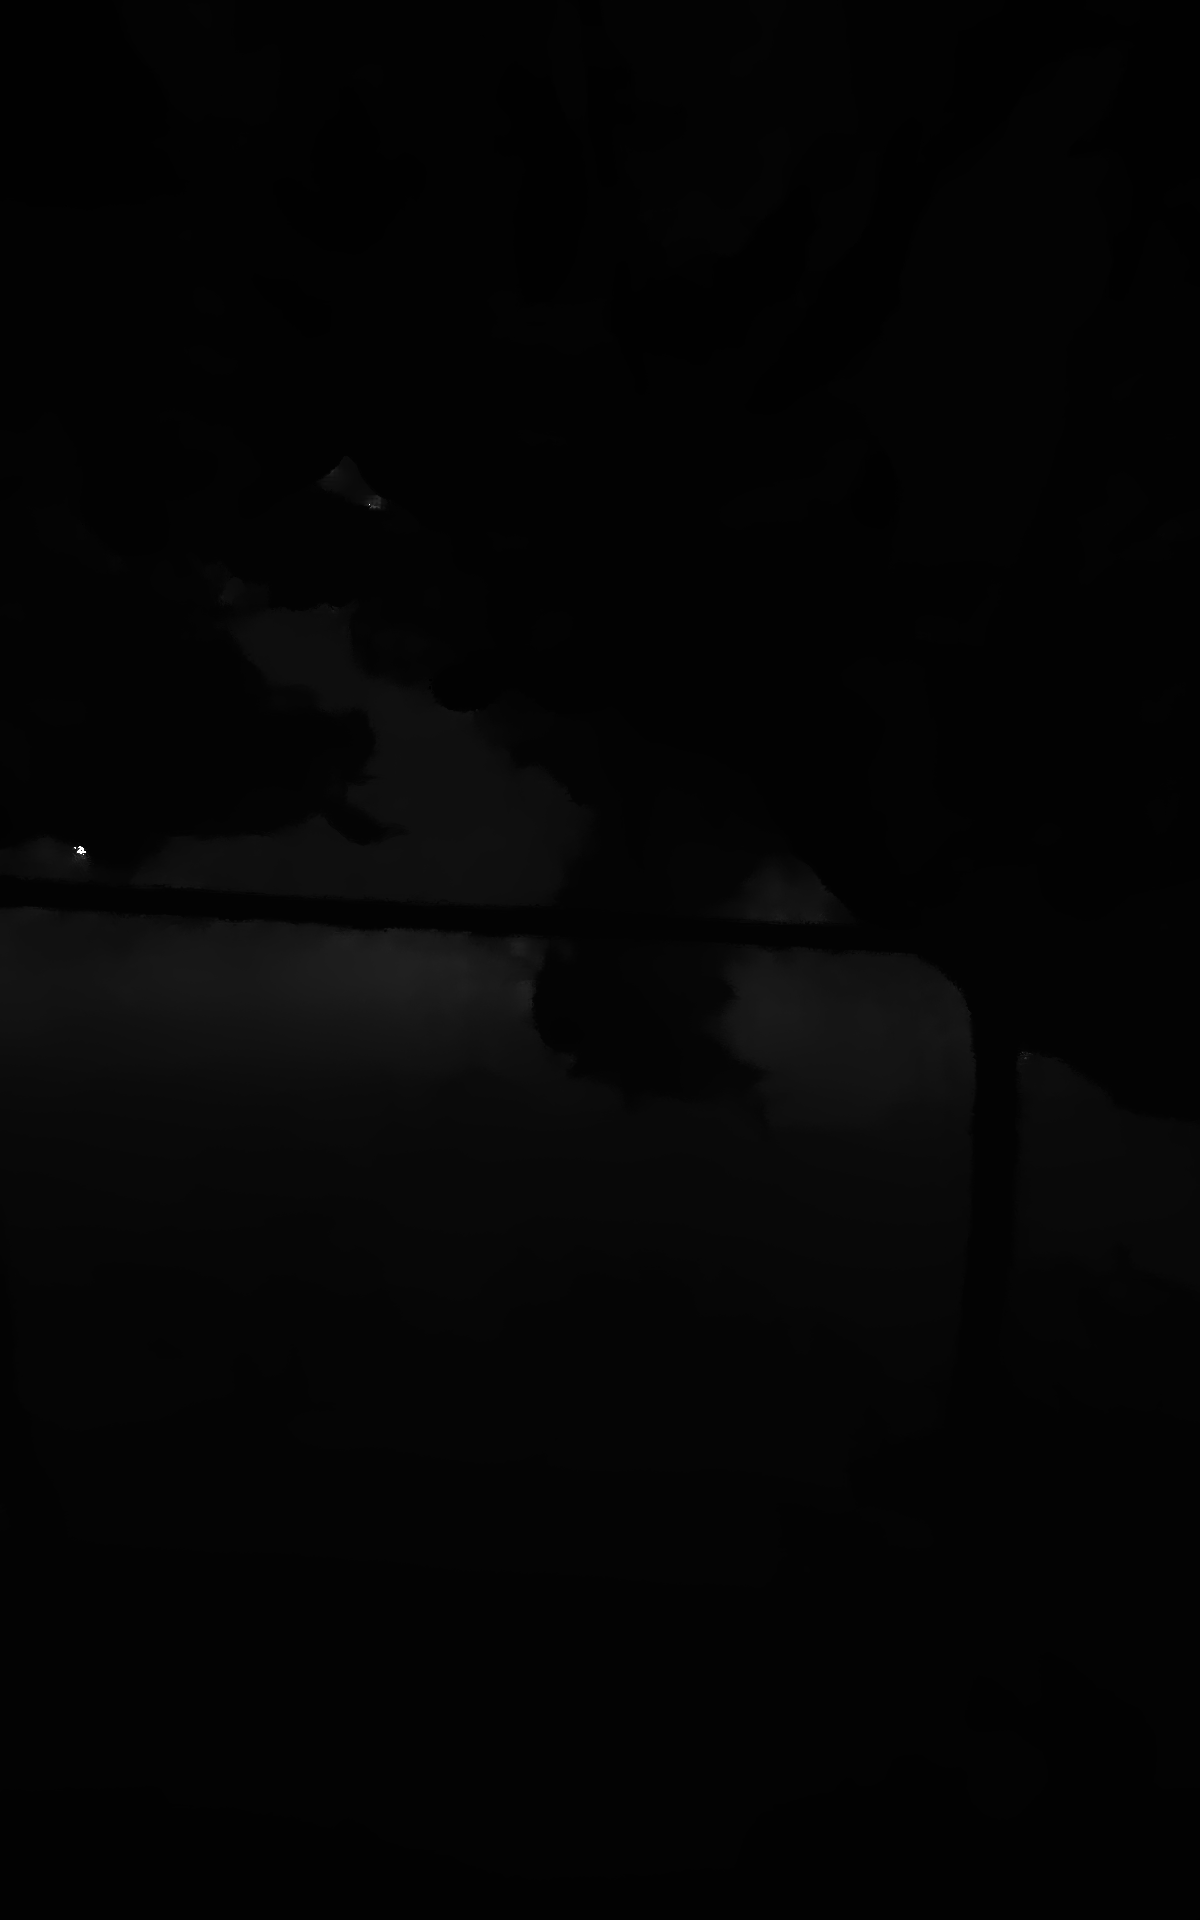

In [21]:
import gdown
import os
from PIL import Image, JpegImagePlugin
from IPython.display import display

evaluation_set_rgb_folder_link = "https://drive.google.com/drive/folders/1Ua9R3pC5HZdiUKPGdoCpS_MKmy6O4_-p?usp=drive_link"

if not os.path.exists("/content/EvaluationSetRGB"):
  print(f'rgb folder: {evaluation_set_rgb_folder_link} is missing, downloading from: {evaluation_set_rgb_folder_link}')
  gdown.download_folder(evaluation_set_rgb_folder_link, quiet=True)
  print(f'rgb folder: {evaluation_set_rgb_folder_link} download done from: {evaluation_set_rgb_folder_link}')


evaluation_set_depth_folder_link = "https://drive.google.com/drive/folders/1V_rZAPt13EFp1k4ouwsSLj9_Fh9L_red?usp=drive_link"

if not os.path.exists("/content/EvaluationSetDepth"):
  print(f'depth folder: {evaluation_set_rgb_folder_link} is missing, downloading from: {evaluation_set_depth_folder_link}')
  gdown.download_folder(evaluation_set_depth_folder_link, quiet=True)
  print(f'depth folder: {evaluation_set_rgb_folder_link} is missing, download done from: {evaluation_set_depth_folder_link}')



# show data from the 25h image
image_index = 25
rgb_image_path = f'/content/EvaluationSetRGB/{image_index:03}_rgb.jpg'
depth_image_path = f'/content/EvaluationSetDepth/{image_index:03}_depth.png'

# Check that the images exists in the Colab filesystem
print("Rgb File downloaded: ", os.path.exists(rgb_image_path), rgb_image_path)
print("Depth File downloaded: ", os.path.exists(depth_image_path), depth_image_path)

# Display the image
one_rgb_image: Image.Image = Image.open(rgb_image_path)
one_depth_image: Image.Image = Image.open(depth_image_path)
pixel_of_interest_x = 100
pixel_of_interest_y = 200

pixel_of_interest_color = one_rgb_image.getpixel((pixel_of_interest_x, pixel_of_interest_y))
pixel_of_interest_depth_color = one_depth_image.getpixel((pixel_of_interest_x, pixel_of_interest_y))

# pixel_of_interest_depth =
print(f'pixel_of_interest_color: {pixel_of_interest_color}')
print(f'pixel_of_interest_color: {pixel_of_interest_depth_color}')
# display(one_rgb_image)
display(one_depth_image)



**Part 2**

In this part, you will train a machine learning model to detect tree trunks. As part of this challenge you should have received a separate folder with two sub-folders, "images" and "labels".

In these folders, there are 30 images of tree trunks, and 30 corresponding annotation files containing masks of the tree trunks.

The amount of labelled training data will be relatively sparse, and while the trunks in the training data will look similar to the ones in the challenge's Evaluation Set, they will not be exactly the same trunks.

Your objective is to architect, tune hyperparameters for, and train a machine learning model to predict per-pixel masks on trunks. If you wish, you may implement existing architectures such as YOLO, Mask-RCNN, etc, as a starting point, but the best results will only be achieved with fine-tuning, re-architecting, and tuning both the structure and hyperparameters of these models. *You will be graded directly on the accuracy and precision of your mask detections, both on the evaluation set and on a separate, unseen test set.*

You should save your trained model and weights as part of this Colab notebook.

**In your comments, please write detailed notes on exactly how you choose to prototype and structure your model, and exactly what design decisions you made and why.**

Also, please ensure that you set appropriate random seeds so that your trained model is reproducible. We will be re-running the training code to reproduce your model upon completion of the challenge.

*Example tree trunk masks*

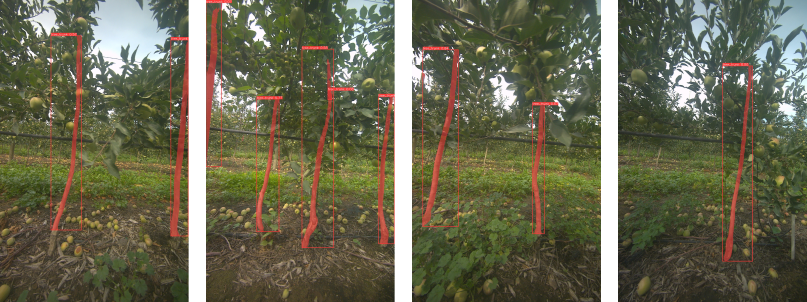

Below, we demonstrate how to download and load in the trunk images and masks, as well as how to parse the mask label files to plot the masks on top of images.

In [ ]:
import gdown
import os

train_set_images_folder_link = "https://drive.google.com/drive/folders/1lC80eJlepgSog6vpe9Ehl1d2IquN8zc4?usp=sharing"
train_set_labels_folder_link = "https://drive.google.com/drive/folders/1RU9x46DFyrUCdVoCy85LBAoMRVASqqeA?usp=sharing"

gdown.download_folder(train_set_images_folder_link, quiet=True)

gdown.download_folder(train_set_labels_folder_link, quiet=True)

# This downloads all of the images in the EvaluationSetRGB google drive folder to Colab's local filesystem. In this case, these files will have downloaded
# 30 images + 30 labels = 60 total files should be downloaded from the RGB folder on google drive, to "/content/Images/" and "/content/Labels/" locally

# Check that an image and corresponding label exists in the Colab filesystem
print("File downloaded: ", os.path.exists("/content/Images/130_rgb.jpg"))
print("File downloaded: ", os.path.exists("/content/Labels/130_label.txt"))

# The labels are stored in the YOLOv5 contour mask format, where each line in the text file represents a separate mask label. Within each line, the first token (an integer) represents a class
# In this case, since there is just one class "Trunk", all of the labels have class = "0". The following N * 2 tokens (all floats) represent the coordinates of each of the points of the mask.
# Together, the points for each label represent individual vertices of a contour / polygon that represents the mask. Each of the points/vertices is represented as "x y ", delineated with spaces.
# In this coordinate frame, (x, y) = (0, 0) at the top left corner of the image. Each X and Y value is a float between 0 and 1, representing the proportion of the image's width/height where the vertex occurs.
# i.e. (x, y) = (0.25, 0.5) would be the point 1/4 from the left of the image, and halfway down the image from the top.

# Each label textfile may have 0, 1, 2, or more masks, each on a new line of the text file.
# Below, we demonstrate how to parse the label file and plot a mask on top of an image.

File downloaded:  True
File downloaded:  True


In [ ]:
import gdown
import cv2
import numpy as np

image_path = "/content/Images/130_rgb.jpg"
label_file_path = "/content/Labels/130_label.txt"

def convert_label_contour(label_line, img_shape):
    parts = label_line.strip().split()
    class_label = int(parts[0])
    if class_label != 0:
        return None
    coordinates = [(float(parts[i]) * img_shape[1], float(parts[i + 1]) * img_shape[0]) for i in range(1, len(parts), 2)]
    return np.int32([coordinates])

# Read the image
image = cv2.imread(image_path)

# Read the label file and plot the labels of each mask as a polygon, filled with green
with open(label_file_path, 'r') as file:
    for line in file:
        contour = convert_label_contour(line, image.shape)
        if contour is not None:
            cv2.fillPoly(image, [contour], (0, 255, 0))

# Save the result
cv2.imwrite("test_mask.jpg", image)

labelled_image = Image.open("test_mask.jpg")
display(labelled_image)

Below is where you write your code to train your ML model to predict masks on trunks

In [ ]:
# Train your ML model here

**Part 3**
In this part, you should provide a code block with inference code, where an input image can be pulled from the internet, be inferenced on, and output + display a result image with a semantically segmented mask of the detected trunk(s), which is displayed in the Colab notebook.

For example, you can test using the example input url https://ik.imagekit.io/orchardrobotics/example_trunk_to_inference.jpg. If this url is put in the inference code block of this Colab notebook, your code should automatically download the image, use it as input to your machine learning model, and then display a resulting image representing where the trunk(s) are.

The output image should be a pixel-wise mask with only two colors occuring in the image. Where white pixels (255, 255, 255) represent pixels that are part of any trunk mask, and black pixels (0, 0, 0) represent everything else.

In [ ]:
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display

# URL of the image
url = 'https://ik.imagekit.io/orchardrobotics/example_trunk_to_inference.jpg'

# Fetch the image
response = requests.get(url)
original_image = Image.open(BytesIO(response.content))


### Run inference using your model here ###
ml_inference_output = original_image
# ml_inference_output should be the pixel-wise mask, with each pixel either (0, 0, 0) or (255, 255, 255) depending on whether it is part of a trunk mask

# Save the image
ml_inference_output.save('test_output_image.jpg')
print("ML Inference Output Image:")
display(ml_inference_output)

# Save the image
ml_inference_output.save('ml_inference_output.jpg')

**Part 4**

In this part, you will need to develop a method to count the total number of trunks in the sequence of Evaluation Set images.

A portion of this will involve using your trained ML model to inference on the RGB images of the trunks in the EvaluationSetRGB folder, to detect the trunks.

Afterwards, your method must be able to count the number of unique trunks in the sequence of images, without undercounting or double-counting any given trunk.


The result of this part should be one number, indicating the total number of trunks in the sequence of 49 images.

In addition, output the inferences of your ML model on each of the 49 images, with the tree mask visible in translucent red, plotted on top of the original RGB image. On top of each mask, plot text indicating the unique ID of each tree. (i.e. if there are 20 unique trees in the sequence of 49 images, the first 4 images might all contain tree 1, the 5th image might contain tree 1 and tree 2, the next 5 images might only contain tree 2, etc. Plot the unique ID assigned to each tree on top of that tree's mask).


In [ ]:
# Count trunks here



# Print total number of trunks

# Display each of the 49 annotated images with masks in translucent red on top of the RGB image, and unique tree IDs on top of each detected mask


**Part 5 (Bonus Points!)**

In this part, you will need to infer the locations of each tree trunk.

It will be important to utilize both your mask predictions and the information from each image's depth map (stored in EvaluationSetDepth).

To accomplish this, you will need a way to localize each unique trunk you see, and then convert those coordinates into a global coordinate frame.

Assume that the location of the first tree is (x, y) = (0 meters, 0 meters), and the camera is moving directly from east to west (i.e. to the left, in the direction of negative X).



In [ ]:
# Infer locations of trunks here

Plot the tree trunk locations below using matplotlab, using the starter code. The first tree trunk should be at (0,0). The gridlines are automatically set to be at 1 meter intervals.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Defining a couple example points (replace these with your predicted tree trunk locations)
points = [(0, 0), (-5, 0), (-10, 5)]

# Plotting the points
for x, y in points:
    plt.scatter(x, y, c='red')
    plt.text(x, y, f'({x}, {y})', fontsize=12)

# Setting gridlines every 1 meter
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(np.arange(min(-10, -10), max(5, 5) + 1, 1))
plt.yticks(np.arange(min(0, -5), max(5, 5) + 1, 1))

plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.show()
